In [1]:
from ImageNet100ValDataset import *

In [2]:
NOISY_DIR = "RFGSM_out"
SELECTED_DIR = "3 clases"
noisy_dataset = ImageNet100ValDataset(NOISY_DIR, transform=transform)
selected_dataset = ImageNet100ValDataset(SELECTED_DIR, transform=transform)
metricas = {}


In [3]:
from Modelos.ResNet50 import evaluate_resnet50
acc_t1_res50, acc_t5_res50 = evaluate_resnet50(SELECTED_DIR)
metricas['ResNet50 selected'] = (acc_t1_res50, acc_t5_res50)
print(f"Top 1 accuracy ResNet50 (selected): {acc_t1_res50}")
print(f"Top 5 accuracy ResNet50 (selected): {acc_t5_res50}")

Top 1 accuracy ResNet50 (selected): 0.9466666666666667
Top 5 accuracy ResNet50 (selected): 1.0


In [4]:
noisy_acc_t1_res50, noisy_acc_t5_res50 = evaluate_resnet50(NOISY_DIR)
metricas['ResNet50 noisy'] = (noisy_acc_t1_res50, noisy_acc_t5_res50)
print(f"Top 1 noisy accuracy ResNet50: {noisy_acc_t1_res50}")
print(f"Top 5 noisy accuracy ResNet50: {noisy_acc_t5_res50}")

Top 1 noisy accuracy ResNet50: 0.8733333333333333
Top 5 noisy accuracy ResNet50: 1.0


In [5]:
from Modelos.ResNet34 import evaluate_resnet34
acc_t1_res34, noisy_acc_t5_res34 = evaluate_resnet34(SELECTED_DIR)
metricas['ResNet34 selected'] = (acc_t1_res34, noisy_acc_t5_res34)
print(f"Top 1 accuracy ResNet34 (selected): {acc_t1_res34}")
print(f"Top 5 accuracy ResNet34 (selected): {noisy_acc_t5_res34}")

Top 1 accuracy ResNet34 (selected): 0.9066666666666666
Top 5 accuracy ResNet34 (selected): 1.0


In [6]:
noisy_acc_t1_res34, noisy_acc_t5_res34 = evaluate_resnet34(NOISY_DIR)
metricas['ResNet34 noisy'] = (noisy_acc_t1_res34, noisy_acc_t5_res34)
print(f"Top 1 noisy accuracy ResNet34: {noisy_acc_t1_res34}")
print(f"Top 5 noisy accuracy ResNet34: {noisy_acc_t5_res34}")

Top 1 noisy accuracy ResNet34: 0.84
Top 5 noisy accuracy ResNet34: 1.0


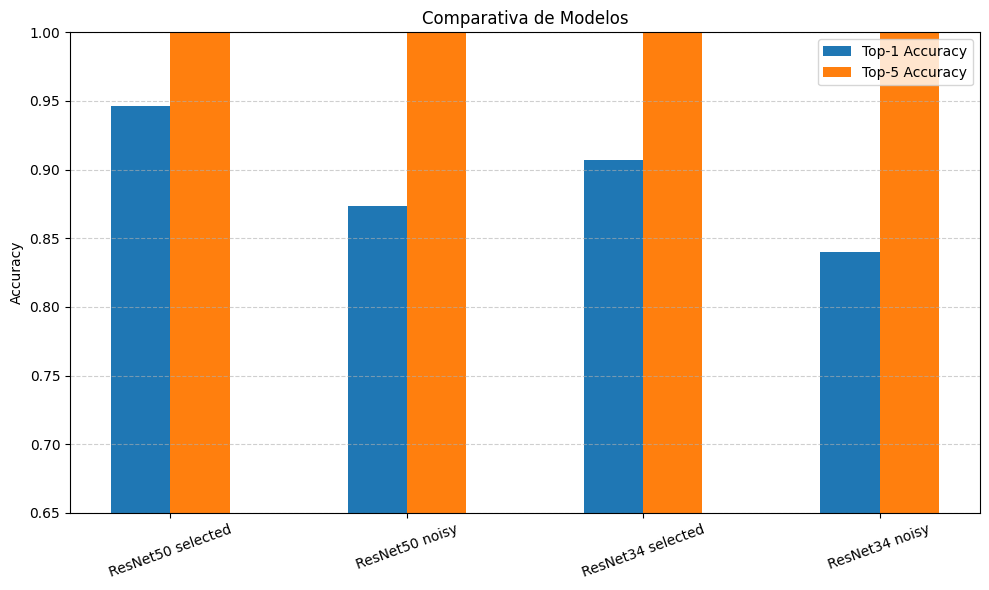

In [7]:
import matplotlib.pyplot as plt
import numpy as np

modelos = list(metricas.keys())
acc_t1 = [metricas[m][0] for m in modelos]
acc_t5 = [metricas[m][1] for m in modelos]

x = np.arange(len(modelos))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, acc_t1, width, label='Top-1 Accuracy')
plt.bar(x + width/2, acc_t5, width, label='Top-5 Accuracy')

plt.xticks(x, modelos, rotation=20)
plt.ylabel('Accuracy')
plt.title('Comparativa de Modelos')
plt.legend()
plt.ylim(0.65, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()